# QQQ vs SPY — Performance & Risk Analysis

This notebook downloads **daily adjusted close prices** for the Invesco QQQ
Trust (QQQ) and the SPDR S&P 500 ETF (SPY), then computes the standard
performance/risk metrics for each:

* **Total return** (buy-and-hold, dividends reinvested via adjusted close)
* **Annualized volatility**
* **Maximum drawdown**
* **Sharpe ratio**
* **Beta** (QQQ vs SPY as the market proxy)
* **CAPM (Jensen's) alpha**

All metric calculations live in the unit-tested `stock101.metrics` module, so
the numbers below are reproducible and covered by `tests/test_metrics.py`.

## Assumptions & Conventions

1. **Data** — daily *adjusted* close prices from Yahoo Finance
   (`auto_adjust=True`). Adjusted close reflects splits and reinvested
   dividends, so buy-and-hold "total return" is captured correctly.
2. **Returns** — *simple* (arithmetic) daily returns, $r_t = p_t/p_{t-1} - 1$,
   not log returns.
3. **Annualization** — 252 trading days per year
   (`stock101.metrics.TRADING_DAYS_PER_YEAR`). Volatility and Sharpe ratio are
   scaled by $\sqrt{252}$; CAPM alpha is scaled by $252$.
4. **Volatility** — *sample* standard deviation of daily returns (ddof=1).
5. **Risk-free rate** — 0.0% by default (an annualized simple rate, divided by
   252 to get the daily rate). Change `RISK_FREE_RATE` below to override.
6. **Market proxy** — SPY is used as the market portfolio for beta and CAPM
   alpha.
7. **Beta** — OLS-style slope $\mathrm{Cov}(r_a, r_m)/\mathrm{Var}(r_m)$ on
   *daily* returns over their common trading days. Daily beta can differ from
   monthly beta.
8. **CAPM alpha** — Jensen's alpha, annualized:
   $(\bar r_a - r_f - \beta(\bar r_m - r_f)) \times 252$.
9. **Max drawdown** — reported as a *negative* fraction (e.g. $-0.35$ = a 35%
   peak-to-trough decline).
10. **No survivorship / fees / taxes** — raw index-ETF returns; no transaction
    costs, management-fee adjustments beyond the ETF NAV, or tax effects.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stock101 import metrics as m
from stock101.data import load_prices

# ---- configuration ---------------------------------------------------------
TICKERS = ["QQQ", "SPY"]
START = "2020-01-01"
END = "2024-12-31"
RISK_FREE_RATE = 0.0      # annualized simple rate (see Assumptions)
MARKET = "SPY"            # market proxy for beta / CAPM alpha
CACHE_DIR = Path("data")

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# Download adjusted closes (cached to disk after first run).
prices = load_prices(TICKERS, START, END, cache_dir=CACHE_DIR)
print(f"Rows: {len(prices)}  |  Range: {prices.index.min():%Y-%m-%d} .. {prices.index.max():%Y-%m-%d}")
print(f"Missing values: {int(prices.isna().sum().sum())}")
prices.head()

Rows: 1257  |  Range: 2020-01-02 .. 2024-12-30
Missing values: 0


,QQQ,SPY
Date,,
2020-01-02,208.0889,296.1253
2020-01-03,206.1828,293.8829
2020-01-06,207.5113,295.0041
2020-01-07,207.4824,294.1746
2020-01-08,209.0419,295.7424


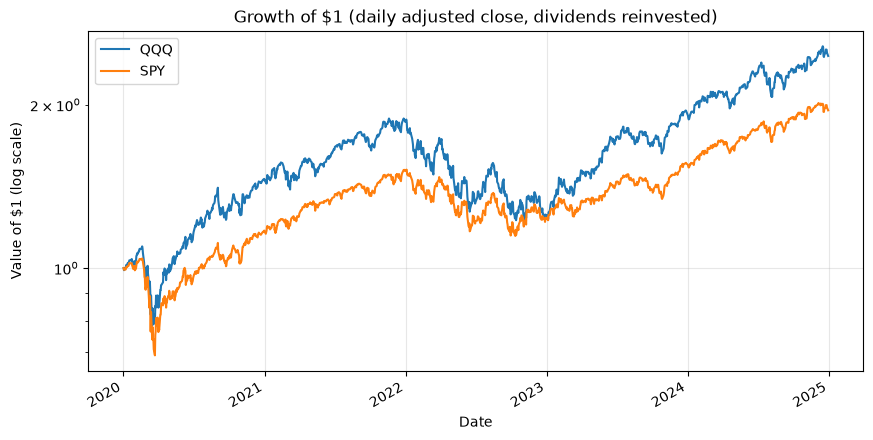

In [3]:
# Growth of $1 invested at the start (log scale is often clearer).
norm = prices / prices.iloc[0]
ax = norm.plot(figsize=(10, 5), logy=True,
               title="Growth of $1 (daily adjusted close, dividends reinvested)")
ax.set_ylabel("Value of $1 (log scale)")
ax.grid(alpha=0.3)
plt.show()

In [4]:
# Daily simple returns for both tickers (aligned on common trading days).
returns = prices.pct_change().dropna()
returns.tail()

,QQQ,SPY
Date,,
2024-12-23,0.0097,0.0060
2024-12-24,0.0136,0.0111
2024-12-26,-0.0007,0.0001
2024-12-27,-0.0133,-0.0105
2024-12-30,-0.0133,-0.0114


In [5]:
def summarize(prices: pd.Series) -> pd.Series:
    ret = prices.pct_change().dropna()
    return pd.Series({
        "Total Return": m.total_return(prices),
        "Annualized Volatility": m.annualized_volatility(ret),
        "Max Drawdown": m.max_drawdown(prices),
        "Sharpe Ratio": m.sharpe_ratio(ret, risk_free_rate=RISK_FREE_RATE),
    })

summary = pd.DataFrame({t: summarize(prices[t]) for t in TICKERS})

# Build a *new* string table for display (never mutate summary in place,
# which pandas 3.0 disallows across dtypes).
formats = {
    "Total Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Max Drawdown": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
}
display = pd.DataFrame(
    {
        ticker: [formats[idx].format(v) for idx, v in summary[ticker].items()]
        for ticker in summary.columns
    },
    index=summary.index,
)
display

,QQQ,SPY
Total Return,145.95%,95.30%
Annualized Volatility,25.65%,21.00%
Max Drawdown,-35.12%,-33.72%
Sharpe Ratio,0.83,0.75


In [6]:
# Beta and CAPM alpha vs the market proxy (SPY).
reg = {}
for ticker in TICKERS:
    if ticker == MARKET:
        continue
    reg[ticker] = {
        "Beta (vs SPY)": m.beta(returns[ticker], returns[MARKET]),
        "CAPM Alpha (annualized)": m.capm_alpha(
            returns[ticker], returns[MARKET], risk_free_rate=RISK_FREE_RATE
        ),
    }

pd.DataFrame(reg).T.map("{:.3f}".format)

,Beta (vs SPY),CAPM Alpha (annualized)
QQQ,1.136,0.036


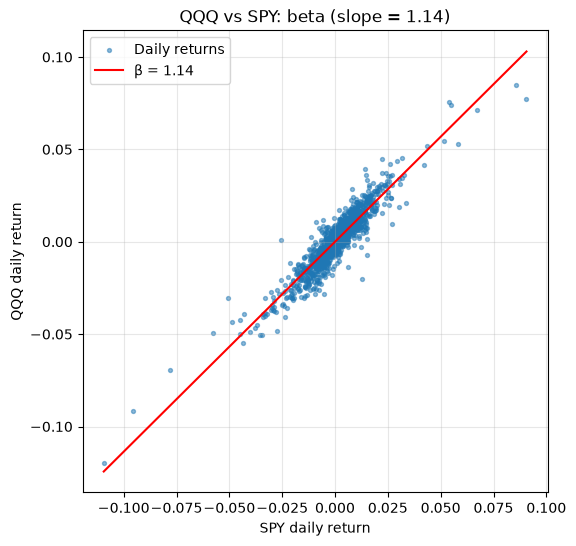

In [7]:
# Visualize the beta regression line (through the origin).
ticker = "QQQ"
b = m.beta(returns[ticker], returns[MARKET])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(returns[MARKET], returns[ticker], s=8, alpha=0.5, label="Daily returns")
x = np.linspace(returns[MARKET].min(), returns[MARKET].max(), 100)
ax.plot(x, b * x, color="red", label=f"β = {b:.2f}")
ax.set_xlabel(f"{MARKET} daily return")
ax.set_ylabel(f"{ticker} daily return")
ax.set_title(f"{ticker} vs {MARKET}: beta (slope = {b:.2f})")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Interpretation

* **Total return** is the buy-and-hold return including reinvested dividends
  (already baked into adjusted close).
* **Annualized volatility** is the annualized standard deviation of daily
  returns — a measure of total risk, not downside risk.
* **Max drawdown** is the worst peak-to-trough decline over the window.
* **Sharpe ratio** is return per unit of total risk, using a 0% risk-free rate
  here; a different `RISK_FREE_RATE` would lower it.
* **Beta** measures sensitivity to the market (SPY). A beta > 1 means the asset
  historically moved more than the market on average.
* **CAPM alpha** is the annualized return above what CAPM predicts given the
  asset's beta; it is only meaningful *conditional* on CAPM holding, and daily
  estimates are noisy.

**Caveats:** daily-return beta/alpha are sensitive to the sample window and to
non-synchronous trading (minor for liquid ETFs). Past performance is not
indicative of future results.

## Reproducing & testing

Recreate the environment and run the unit tests::

    uv venv .venv && uv pip install --python .venv/bin/python -r requirements.txt
    .venv/bin/python -m pytest

Regenerate this notebook from source::

    .venv/bin/python build_notebook.py